In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [16]:
df = pd.read_csv("/Users/ayushmishra06/Desktop/Lenovo/lenovo-project/machinelearning/data/realistic_power_emergency_dataset.csv")
df.head(20)

,Timestamp,Server_ID,CPU_Utilization_%,Memory_Utilization_%,Power_Usage_Watts
0,2026-01-01 00:00:00,S1,56.996777,56.624109,122.483571
1,2026-01-01 00:05:00,S1,55.566240,59.749040,121.194277
2,2026-01-01 00:10:00,S1,52.182197,56.980700,127.002184
3,2026-01-01 00:15:00,S1,49.586143,59.873226,133.242149
4,2026-01-01 00:20:00,S1,57.242450,52.413797,126.297240
5,2026-01-01 00:25:00,S1,56.640921,63.415315,128.108797
6,2026-01-01 00:30:00,S1,60.061224,62.819527,138.950326
7,2026-01-01 00:35:00,S1,59.660455,59.189928,136.622502
8,2026-01-01 00:40:00,S1,62.617271,67.030232,132.118464
9,2026-01-01 00:45:00,S1,55.561849,68.876794,138.801940


In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Timestamp             3000 non-null   str    
 1   Server_ID             3000 non-null   str    
 2   CPU_Utilization_%     3000 non-null   float64
 3   Memory_Utilization_%  3000 non-null   float64
 4   Power_Usage_Watts     3000 non-null   float64
dtypes: float64(3), str(2)
memory usage: 117.3 KB


In [18]:
df_s1 = df[df['Server_ID'] == 'S1'].copy()
df_s2 = df[df['Server_ID'] == 'S2'].copy()
df_s3 = df[df['Server_ID'] == 'S3'].copy()

In [19]:
df_s2.shape

(1000, 5)

In [24]:
df_s1['Timestamp'] = pd.to_datetime(df_s1['Timestamp'])
df_s1 = df_s1.sort_values(by='Timestamp')

In [25]:
df_s1.head(20)

,Timestamp,Server_ID,CPU_Utilization_%,Memory_Utilization_%,Power_Usage_Watts
0,2026-01-01 00:00:00,S1,56.996777,56.624109,122.483571
1,2026-01-01 00:05:00,S1,55.566240,59.749040,121.194277
2,2026-01-01 00:10:00,S1,52.182197,56.980700,127.002184
3,2026-01-01 00:15:00,S1,49.586143,59.873226,133.242149
4,2026-01-01 00:20:00,S1,57.242450,52.413797,126.297240
5,2026-01-01 00:25:00,S1,56.640921,63.415315,128.108797
6,2026-01-01 00:30:00,S1,60.061224,62.819527,138.950326
7,2026-01-01 00:35:00,S1,59.660455,59.189928,136.622502
8,2026-01-01 00:40:00,S1,62.617271,67.030232,132.118464
9,2026-01-01 00:45:00,S1,55.561849,68.876794,138.801940


In [26]:
df_s1.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Timestamp             1000 non-null   datetime64[us]
 1   Server_ID             1000 non-null   str           
 2   CPU_Utilization_%     1000 non-null   float64       
 3   Memory_Utilization_%  1000 non-null   float64       
 4   Power_Usage_Watts     1000 non-null   float64       
dtypes: datetime64[us](1), float64(3), str(1)
memory usage: 39.2 KB


In [27]:
df_s1['hour'] = df_s1['Timestamp'].dt.hour
df_s1['minute'] = df_s1['Timestamp'].dt.minute
df_s1['day_of_week'] = df_s1['Timestamp'].dt.dayofweek

In [28]:
df_s1['day_of_week']

0      3
1      3
2      3
3      3
4      3
      ..
995    6
996    6
997    6
998    6
999    6
Name: day_of_week, Length: 1000, dtype: int32

In [29]:
df_s1['cpu_change'] = df_s1['CPU_Utilization_%'].diff()
df_s1['memory_change'] = df_s1['Memory_Utilization_%'].diff()
df_s1['power_change'] = df_s1['Power_Usage_Watts'].diff()

In [30]:
df_s1

,Timestamp,Server_ID,CPU_Utilization_%,Memory_Utilization_%,Power_Usage_Watts,hour,minute,day_of_week,cpu_change,memory_change,power_change
0,2026-01-01 00:00:00,S1,56.996777,56.624109,122.483571,0,0,3,NaN,NaN,NaN
1,2026-01-01 00:05:00,S1,55.566240,59.749040,121.194277,0,5,3,-1.430537,3.124931,-1.289294
2,2026-01-01 00:10:00,S1,52.182197,56.980700,127.002184,0,10,3,-3.384043,-2.768340,5.807906
3,2026-01-01 00:15:00,S1,49.586143,59.873226,133.242149,0,15,3,-2.596054,2.892526,6.239965
4,2026-01-01 00:20:00,S1,57.242450,52.413797,126.297240,0,20,3,7.656307,-7.459429,-6.944909
...,...,...,...,...,...,...,...,...,...,...,...
995,2026-01-04 10:55:00,S1,59.102084,58.505532,111.126492,10,55,6,2.671349,5.613971,5.414074
996,2026-01-04 11:00:00,S1,52.688220,59.875729,123.361433,11,0,6,-6.413864,1.370197,12.234941
997,2026-01-04 11:05:00,S1,47.474671,52.848398,119.440473,11,5,6,-5.213549,-7.027331,-3.920960
998,2026-01-04 11:10:00,S1,50.127737,61.199249,115.258506,11,10,6,2.653065,8.350851,-4.181967


In [31]:
df_s1['cpu_rolling_mean'] = df_s1['CPU_Utilization_%'].rolling(5).mean()
df_s1['power_rolling_mean'] = df_s1['Power_Usage_Watts'].rolling(5).mean()
df_s1['power_deviation'] = df_s1['Power_Usage_Watts'] - df_s1['power_rolling_mean']
df_s1['cpu_deviation'] = df_s1['CPU_Utilization_%'] - df_s1['cpu_rolling_mean']

In [32]:
df_s1

,Timestamp,Server_ID,CPU_Utilization_%,Memory_Utilization_%,Power_Usage_Watts,hour,minute,day_of_week,cpu_change,memory_change,power_change,cpu_rolling_mean,power_rolling_mean,power_deviation,cpu_deviation
0,2026-01-01 00:00:00,S1,56.996777,56.624109,122.483571,0,0,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2026-01-01 00:05:00,S1,55.566240,59.749040,121.194277,0,5,3,-1.430537,3.124931,-1.289294,NaN,NaN,NaN,NaN
2,2026-01-01 00:10:00,S1,52.182197,56.980700,127.002184,0,10,3,-3.384043,-2.768340,5.807906,NaN,NaN,NaN,NaN
3,2026-01-01 00:15:00,S1,49.586143,59.873226,133.242149,0,15,3,-2.596054,2.892526,6.239965,NaN,NaN,NaN,NaN
4,2026-01-01 00:20:00,S1,57.242450,52.413797,126.297240,0,20,3,7.656307,-7.459429,-6.944909,54.314761,126.043884,0.253356,2.927688
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,2026-01-04 10:55:00,S1,59.102084,58.505532,111.126492,10,55,6,2.671349,5.613971,5.414074,59.645945,104.735800,6.390692,-0.543860
996,2026-01-04 11:00:00,S1,52.688220,59.875729,123.361433,11,0,6,-6.413864,1.370197,12.234941,57.955396,110.342989,13.018444,-5.267176
997,2026-01-04 11:05:00,S1,47.474671,52.848398,119.440473,11,5,6,-5.213549,-7.027331,-3.920960,54.964498,113.035327,6.405147,-7.489826
998,2026-01-04 11:10:00,S1,50.127737,61.199249,115.258506,11,10,6,2.653065,8.350851,-4.181967,53.164690,114.979865,0.278642,-3.036953


In [33]:
df_s1 = df_s1.dropna()

In [34]:
features = [
    'CPU_Utilization_%',
    'Memory_Utilization_%',
    # 'Power_Usage_Watts',

    'cpu_change',
    'memory_change',
    'power_change',

    'cpu_rolling_mean',
    'power_rolling_mean',

    'cpu_deviation',
    'power_deviation',

    'hour',
    'day_of_week'
]

In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_s1[features])

In [36]:
# train_size = int(len(df_s1) * 0.7)
#
# X_train = X_scaled[:train_size]
# X_test = X_scaled[train_size:]
# from sklearn.ensemble import IsolationForest
#
# model = IsolationForest(
#     n_estimators=150,
#     contamination=0.01,
#     random_state=42
# )
#
# model.fit(X_train)
#
# df_s1['anomaly'] = model.decision_function(X_scaled)

In [37]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(
    n_estimators=150,
    contamination=0.05,
    random_state=42
)

df_s1['anomaly'] = model.fit_predict(X_scaled)

In [38]:
df_s1

,Timestamp,Server_ID,CPU_Utilization_%,Memory_Utilization_%,Power_Usage_Watts,hour,minute,day_of_week,cpu_change,memory_change,power_change,cpu_rolling_mean,power_rolling_mean,power_deviation,cpu_deviation,anomaly
4,2026-01-01 00:20:00,S1,57.242450,52.413797,126.297240,0,20,3,7.656307,-7.459429,-6.944909,54.314761,126.043884,0.253356,2.927688,1
5,2026-01-01 00:25:00,S1,56.640921,63.415315,128.108797,0,25,3,-0.601529,11.001518,1.811557,54.243590,127.168929,0.939868,2.397331,1
6,2026-01-01 00:30:00,S1,60.061224,62.819527,138.950326,0,30,3,3.420303,-0.595788,10.841529,55.142587,130.720139,8.230187,4.918637,1
7,2026-01-01 00:35:00,S1,59.660455,59.189928,136.622502,0,35,3,-0.400769,-3.629599,-2.327824,56.638238,132.644203,3.978299,3.022217,1
8,2026-01-01 00:40:00,S1,62.617271,67.030232,132.118464,0,40,3,2.956817,7.840304,-4.504038,59.244464,132.419466,-0.301002,3.372807,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,2026-01-04 10:55:00,S1,59.102084,58.505532,111.126492,10,55,6,2.671349,5.613971,5.414074,59.645945,104.735800,6.390692,-0.543860,1
996,2026-01-04 11:00:00,S1,52.688220,59.875729,123.361433,11,0,6,-6.413864,1.370197,12.234941,57.955396,110.342989,13.018444,-5.267176,1
997,2026-01-04 11:05:00,S1,47.474671,52.848398,119.440473,11,5,6,-5.213549,-7.027331,-3.920960,54.964498,113.035327,6.405147,-7.489826,1
998,2026-01-04 11:10:00,S1,50.127737,61.199249,115.258506,11,10,6,2.653065,8.350851,-4.181967,53.164690,114.979865,0.278642,-3.036953,1


In [39]:
df_s1['anomaly_flag'] = df_s1['anomaly'].apply(lambda x: 1 if x == -1 else 0)

In [40]:
df_s1.shape

(996, 17)

In [41]:
print("df_s1 shape:", df_s1.shape)
print("Power length:", len(df_s1['Power_Usage_Watts']))

df_s1 shape: (996, 17)
Power length: 996


In [42]:
df_s1 = df_s1.sort_values(by='Timestamp').reset_index(drop=True)

In [43]:
scores = model.decision_function(X_scaled)
df_s1['anomaly_score'] = scores

threshold = np.percentile(scores, 5)  # top 4% strongest anomalies
df_s1['strong_anomaly'] = df_s1['anomaly_score'] < threshold

In [44]:
start = 0
end = 9000 # change this window to explore

subset = df_s1.iloc[start:end]

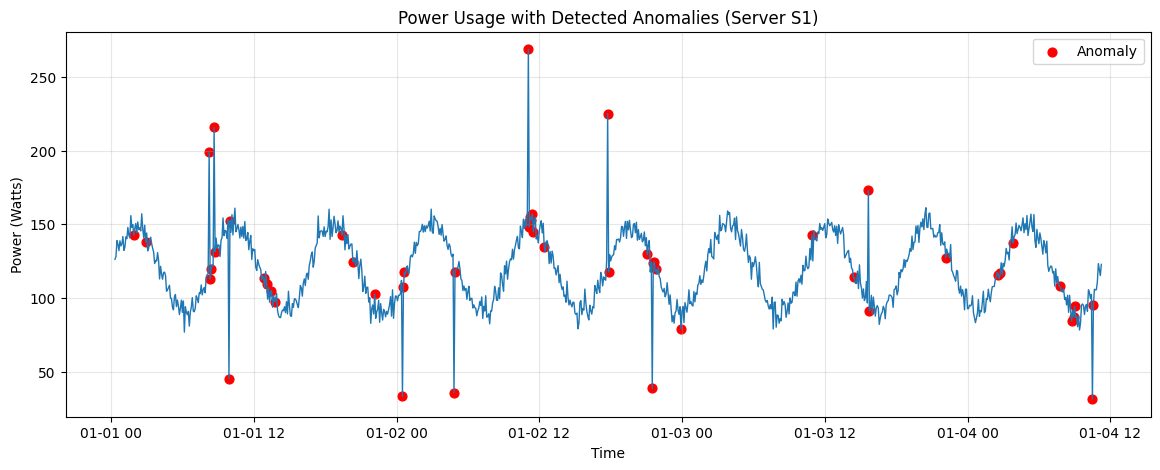

In [45]:

plt.figure(figsize=(14,5))

plt.plot(subset['Timestamp'], subset['Power_Usage_Watts'], linewidth=1)

plt.scatter(
    subset['Timestamp'][subset['strong_anomaly']],
    subset['Power_Usage_Watts'][subset['strong_anomaly']],
    color='red',
    s=40,
    label='Anomaly'
)

plt.title("Power Usage with Detected Anomalies (Server S1)")
plt.xlabel("Time")
plt.ylabel("Power (Watts)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [46]:
df_s1.sample(10)

,Timestamp,Server_ID,CPU_Utilization_%,Memory_Utilization_%,Power_Usage_Watts,hour,minute,day_of_week,cpu_change,memory_change,power_change,cpu_rolling_mean,power_rolling_mean,power_deviation,cpu_deviation,anomaly,anomaly_flag,anomaly_score,strong_anomaly
247,2026-01-01 20:55:00,S1,40.883478,82.544187,122.233186,20,55,3,3.203458,8.182396,9.009297,34.471360,122.583102,-0.349917,6.412117,1,0,0.028437,False
136,2026-01-01 11:40:00,S1,54.818001,46.537687,138.556468,11,40,3,-4.091697,8.010601,5.790882,55.442716,138.970235,-0.413767,-0.624715,1,0,0.089643,False
553,2026-01-02 22:25:00,S1,64.169613,45.437684,104.120915,22,25,4,-8.171088,13.299337,-1.428854,66.706404,109.039921,-4.919006,-2.536791,1,0,0.052263,False
586,2026-01-03 01:10:00,S1,53.219712,61.817406,103.636834,1,10,5,-6.633742,6.953829,6.170739,58.217147,99.100717,4.536117,-4.997435,1,0,0.078369,False
224,2026-01-01 19:00:00,S1,35.395361,62.293256,145.808460,19,0,3,5.308104,-6.026817,1.490457,31.698815,148.681065,-2.872605,3.696545,1,0,0.065924,False
620,2026-01-03 04:00:00,S1,41.027169,72.529600,157.957589,4,0,5,12.310557,-4.660895,1.342602,33.332205,154.050334,3.907255,7.694963,1,0,0.030779,False
389,2026-01-02 08:45:00,S1,44.556196,53.658895,117.058704,8,45,4,-8.493339,4.692509,17.460000,43.303602,104.141764,12.916940,1.252594,1,0,0.056557,False
718,2026-01-03 12:10:00,S1,63.282796,44.884172,142.952494,12,10,5,4.174835,-3.127141,2.137508,62.440926,145.636720,-2.684226,0.841869,1,0,0.087996,False
214,2026-01-01 18:10:00,S1,30.685830,78.622646,144.890573,18,10,3,-6.204901,11.229760,-0.409331,35.914945,144.393627,0.496947,-5.229115,1,0,0.041176,False
398,2026-01-02 09:30:00,S1,58.187898,58.397631,124.537463,9,30,4,4.184805,-3.146655,4.896171,51.595473,119.686393,4.851070,6.592426,1,0,0.100339,False


In [47]:
# Compare the mean values of features for Normal vs. Anomalous points
profiling_metrics = df_s1.groupby('strong_anomaly')[['Power_Usage_Watts', 'CPU_Utilization_%', 'cpu_change']].mean()
print(profiling_metrics)

                Power_Usage_Watts  CPU_Utilization_%  cpu_change
strong_anomaly                                                  
False                  119.981445          50.977032   -0.175321
True                   122.075062          52.945625    3.250860


In [48]:
anomaly_count = df_s1['strong_anomaly'].sum()
total_count = len(df_s1)
anomaly_rate = (anomaly_count / total_count) * 100

print(f"Total Anomalies: {anomaly_count}")
print(f"Anomaly Rate: {anomaly_rate:.2f}%")

Total Anomalies: 50
Anomaly Rate: 5.02%


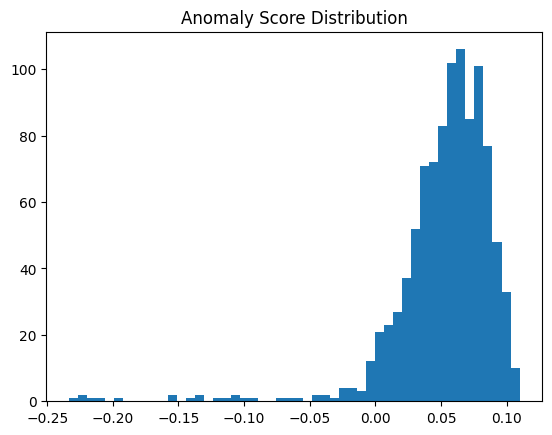

In [49]:
import matplotlib.pyplot as plt

plt.hist(df_s1['anomaly_score'], bins=50)
plt.title("Anomaly Score Distribution")
plt.show()